# UdaciSense: Optimized Object Recognition

## Notebook 1: Baseline Performance

In this notebook, you'll establish the baseline performance of the computer vision model. This will serve as the reference point for your optimization efforts.

Remember, the CTO has set specific requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

## Baseline Analysis

The baseline model establishes the reference point for all optimization experiments. 
The key metrics evaluated are model size, inference latency, and test accuracy.

These metrics are important because UdaciSense targets mobile and budget-friendly devices, where storage, memory, CPU usage, and battery consumption are constrained.

### Step 1. Set up the environment

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [5]:
# Import libraries
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset

# Fix Python path to import custom project modules
import sys
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Current directory: {current_dir}")
print(f"Project root added to path: {project_root}")

# Import custom modules
from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, print_model_summary, train_model
from utils.evaluation import calculate_confusion_matrix, evaluate_model_metrics
from utils.visualization import plot_confusion_matrix, plot_training_history, plot_weight_distribution

Current directory: /workspace/code/project/starter-kit/notebooks
Project root added to path: /workspace/code/project/starter-kit


In [6]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

# Set device to cuda, if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']
Using device: cuda


In [7]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    # Basic seed setting
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For some PyTorch operations
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    # For DataLoader workers
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

In [8]:
# Create directories
model_type = "baseline_mobilenet"
models_dir = f"../models/{model_type}"
models_ckp_dir = f"{models_dir}/checkpoints"
results_dir = f"../results/{model_type}"

os.makedirs(models_ckp_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

### Step 2. Load the dataset

Extracting household classes from CIFAR100 for train set...


100.0%


Extracting ../data/complete/cifar-100-python.tar.gz to ../data/complete
Saving the household subset as raw images at ../data/household_images/train.
Saved 5000 images to ../data/household_images/train
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Saving the household subset as raw images at ../data/household_images/test.
Saved 1000 images to ../data/household_images/test
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


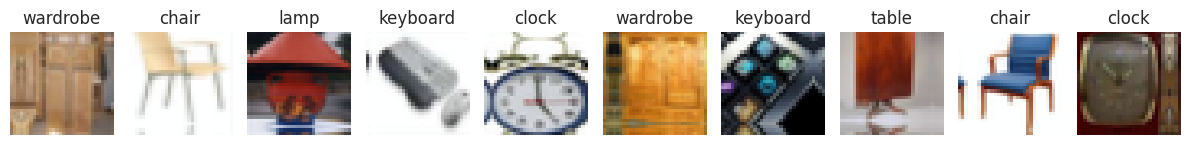


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


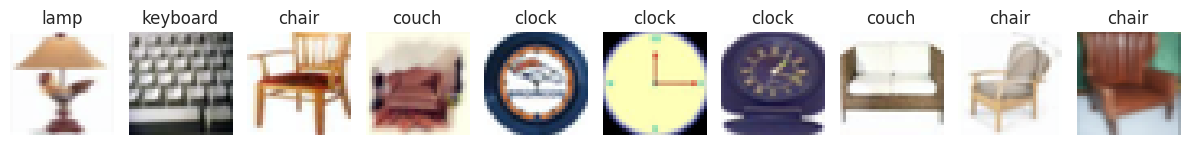

In [9]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Train the baseline model

In [10]:
# Initialize model
model = MobileNetV3_Household().to(device)
print_model_summary(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100.0%


Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

In [11]:
# Define training configuration
num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,  # Note that MobileNet is sensitive to high LRs
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.005,  # Peak learning rate
    steps_per_epoch=len(train_loader),
    epochs=num_epochs,
    pct_start=0.3,  # Spend 30% of training time warming up
    div_factor=25,  # Initial LR is max_lr/25
    final_div_factor=1000  # Final LR is max_lr/1000
)

training_config = {
    'num_epochs': num_epochs,
    'criterion': criterion,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'patience': 5,
    'device': device
}

In [12]:
# Train model given the training_config
training_stats, best_accuracy, best_epoch = train_model(
    model,
    train_loader,
    test_loader,
    training_config,
    checkpoint_path=f"{models_ckp_dir}/model.pth",
)

# Save training statistics
with open(f"{results_dir}/training_stats.json", 'w') as f:
    json.dump(training_stats, f, indent=4)

Total parameters: 1,528,106
Training with standard method for 50 epochs


Epoch 1/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 10.73it/s, loss=1.05, acc=64]  


Epoch 1/50 - Train Loss: 1.5927, Train Acc: 52.76%, Test Loss: 1.0530, Test Acc: 64.00%, LR: 0.000200, Time: 9.08s
New best model! Saving... (64.00%)
Model saved to ../models/baseline_mobilenet/checkpoints/model.pth


Epoch 2/50 [Test]: 100%|██████████| 8/8 [00:01<00:00,  7.25it/s, loss=0.897, acc=73.3]


Epoch 2/50 - Train Loss: 0.7680, Train Acc: 74.08%, Test Loss: 0.7845, Test Acc: 73.30%, LR: 0.000200, Time: 6.50s
New best model! Saving... (73.30%)
Model saved to ../models/baseline_mobilenet/checkpoints/model.pth


...

Epoch 16/50 - Train Loss: 0.0730, Train Acc: 97.58%, Test Loss: 0.4962, Test Acc: 87.50%, LR: 0.000208, Time: 6.70s


Epoch 17/50 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.68it/s, loss=0.479, acc=86.9]


Epoch 17/50 - Train Loss: 0.0686, Train Acc: 97.58%, Test Loss: 0.4787, Test Acc: 86.90%, LR: 0.000210, Time: 6.83s


Epoch 18/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 10.83it/s, loss=0.764, acc=87.6]

Epoch 18/50 - Train Loss: 0.0500, Train Acc: 98.48%, Test Loss: 0.4776, Test Acc: 87.60%, LR: 0.000211, Time: 6.63s
Early stopping at epoch 18. No improvement for 5 epochs.
Training completed. Best accuracy: 87.80%
Best model saved as '../models/baseline_mobilenet/checkpoints/model.pth' at epoch 13


## Compression Opportunities

Based on the baseline architecture, the most promising optimization opportunities are:

1. Quantization, because it can reduce model size and accelerate inference by using lower-precision numerical formats.
2. Pruning, because convolutional and linear layers often contain redundant weights that can be removed with limited accuracy loss.
3. Knowledge distillation, because a smaller student model can learn from the baseline model while improving deployment efficiency.
4. Mobile graph optimization, because TorchScript/mobile-specific optimizations can remove unnecessary graph operations and improve runtime performance.

## Baseline Results and Compression Strategy Analysis

The baseline model for UdaciSense is based on a MobileNetV3 architecture adapted for household object recognition. The dataset contains 10 household object classes: clock, keyboard, lamp, telephone, television, bed, chair, couch, table, and wardrobe. The training set includes 5,000 images and the test set includes 1,000 images, with a balanced distribution of 500 training samples and 100 test samples per class.

The baseline model contains 1,528,106 parameters and achieved a best test accuracy of 87.80% at epoch 13. This baseline accuracy provides the reference point for all future compression experiments. Since the project requires maintaining accuracy within 5% of the baseline, the optimized model should ideally remain close to this accuracy while reducing model size and inference latency.

### Baseline Performance to Optimize From

The main baseline characteristics are:

- Model architecture: MobileNetV3_Household
- Total parameters: 1,528,106
- Best validation/test accuracy: 87.80%
- Best epoch: 13
- Dataset size: 5,000 training images and 1,000 test images
- Number of classes: 10 household object categories
- Target deployment scenario: mobile and budget-friendly smartphones

Although MobileNetV3 is already designed as an efficient neural network architecture, there is still optimization potential for mobile deployment. The model includes convolutional layers, depthwise separable convolutions, squeeze-and-excitation blocks, batch normalization layers, activation functions, and classifier layers. These components provide good accuracy with relatively low parameter count, but they can still benefit from compression techniques such as quantization, pruning, and mobile-specific graph optimization.

### MobileNetV3 Optimization Potential

MobileNetV3 is a strong baseline for mobile vision tasks because it was designed with efficiency in mind. It uses lightweight convolutional blocks and efficient activation functions, which already reduce computational cost compared with larger CNN architectures. However, this also means that compression must be applied carefully. Since the architecture is already compact, aggressive compression could lead to a noticeable accuracy drop.

The most promising opportunities are likely to come from reducing numerical precision and removing redundant weights rather than drastically changing the architecture. Quantization is especially relevant because mobile CPUs can often benefit from lower-precision operations. Pruning can also help identify redundant weights, although its real speed impact depends on whether the resulting sparsity is supported efficiently by the inference backend.

### Recommended Compression Techniques

The first recommended technique is post-training quantization. Quantization reduces the precision of model weights and/or activations, commonly from 32-bit floating point values to lower precision formats such as 8-bit integers. This can significantly reduce model size and may improve CPU inference time. It is especially appropriate for the UdaciSense use case because the target environment is mobile devices, where memory usage, latency, and battery consumption are important constraints.

The second recommended technique is pruning with fine-tuning. Pruning removes less important weights from the model, creating sparsity and reducing redundancy. Since the baseline model achieved strong accuracy, some weights may be removable with limited impact on performance. Fine-tuning after pruning is important because it allows the model to recover part of the accuracy that may be lost during compression.

A third promising technique is knowledge distillation. In this approach, the baseline MobileNetV3 model can act as a teacher model, while a smaller student model learns from its predictions. This can be useful if pruning and quantization alone are not enough to meet the target model size and inference speed requirements. Distillation is particularly valuable because it can preserve accuracy better than training a smaller model only from hard labels.

Finally, mobile graph optimization should be applied during deployment. After selecting the best compressed model, TorchScript and PyTorch Mobile optimization can be used to prepare the model for mobile inference. This step may remove unnecessary operations, optimize the computation graph, and package the model in a mobile-friendly format.

### Expected Trade-Offs

The main trade-off in this project is between model size, inference speed, and accuracy. Quantization is expected to provide a strong reduction in model size with limited accuracy loss, but some layers may be more sensitive to reduced precision. Pruning can reduce redundancy, but if the pruning ratio is too aggressive, it may remove useful weights and reduce classification accuracy. Knowledge distillation can improve the accuracy of a smaller model, but it requires additional training and careful tuning of the distillation loss.

Because MobileNetV3 is already efficient, a single compression technique may not be enough to meet all project requirements. A multi-stage pipeline is likely to provide better results than applying only one method.

### Recommended Multi-Stage Approach

The most promising multi-stage compression strategy is:

1. Start with the trained baseline MobileNetV3 model.
2. Apply pruning to remove redundant weights.
3. Fine-tune the pruned model to recover accuracy.
4. Apply post-training quantization to reduce model size and improve inference efficiency.
5. Convert the optimized model to a mobile-ready format using TorchScript and PyTorch Mobile optimization.

This sequence is appropriate because pruning first reduces model redundancy, fine-tuning helps recover lost accuracy, and quantization then compresses the numerical representation of the remaining model. Mobile-specific optimization is best applied at the end because it prepares the final selected model for deployment.

### Final Recommendation

For the next notebook, the two main compression techniques to implement should be:

- Post-training quantization
- Pruning with fine-tuning

If time allows, knowledge distillation should also be explored as an additional in-training compression method. These techniques provide a balanced optimization strategy and directly address the project goals of reducing model size, improving inference speed, and maintaining accuracy within an acceptable range of the baseline.

# Optimization Analysis for UdaciSense Computer Vision Model

## Baseline Performance Summary

The baseline model for UdaciSense is a MobileNetV3-based computer vision model adapted for household object recognition. The model was trained and evaluated on a balanced subset of household object classes extracted from CIFAR-100.

The dataset includes 10 household object categories:

- clock
- keyboard
- lamp
- telephone
- television
- bed
- chair
- couch
- table
- wardrobe

The training set contains 5,000 images, with 500 images per class. The test set contains 1,000 images, with 100 images per class. This balanced class distribution is useful because it makes accuracy easier to interpret and reduces the risk that the baseline metric is dominated by a few frequent classes.

The baseline model contains 1,528,106 parameters and achieved a best test accuracy of 87.80% at epoch 13. This result establishes the reference point for all later compression experiments. Since the project requires maintaining accuracy within 5% of the baseline, the optimized model should preserve accuracy as much as possible while reducing model size and inference latency.

## MobileNetV3 Architecture Considerations

MobileNetV3 is already designed as an efficient mobile-friendly architecture. It uses lightweight convolutional blocks, depthwise separable convolutions, squeeze-and-excitation modules, and efficient activation functions. These design choices make it much smaller and faster than traditional convolutional neural networks.

However, even though MobileNetV3 is already optimized for mobile scenarios, there are still opportunities for additional compression. The model still uses floating-point weights, contains more than 1.5 million parameters, and includes convolutional and classifier layers that may contain redundant information. For a mobile application such as UdaciSense, reducing memory usage and inference latency is important because users expect fast object recognition with low battery consumption, especially on mid-range and budget-friendly smartphones.

Because the baseline architecture is already compact, compression needs to be applied carefully. Very aggressive compression could reduce model size and inference time, but it may also damage accuracy. Therefore, the best strategy is to combine several moderate optimization techniques instead of relying on one aggressive technique.

## Most Promising Compression Techniques

### 1. Post-Training Quantization

Post-training quantization is one of the most promising techniques for this project. It reduces numerical precision, commonly from 32-bit floating point values to lower precision formats such as 8-bit integers. This can significantly reduce model size and may improve inference speed on CPU-based mobile devices.

This technique is suitable for UdaciSense because mobile devices are constrained by memory bandwidth, storage, CPU performance, and battery usage. Quantization directly addresses these constraints by making the model lighter and potentially faster without requiring a full retraining process.

The expected trade-off is that some accuracy may be lost due to reduced numerical precision. However, because MobileNetV3 is a robust pretrained architecture and the baseline accuracy is strong, moderate quantization is likely to preserve acceptable performance.

### 2. Pruning with Fine-Tuning

Pruning is another strong candidate for this model. Pruning removes weights that contribute less to the final prediction, creating a sparser model. In convolutional neural networks, many parameters may be redundant, especially after fine-tuning on a smaller task-specific dataset.

For UdaciSense, pruning can help reduce unnecessary computation and model complexity. However, pruning alone can reduce accuracy if too many weights are removed. Therefore, pruning should be followed by fine-tuning. Fine-tuning allows the model to adjust after compression and recover some of the lost accuracy.

The expected trade-off is that pruning can improve compression, but its real inference speed benefit depends on whether the deployment runtime can take advantage of sparsity. Even if pruning does not always produce a direct speedup by itself, it can still be valuable when combined with fine-tuning and quantization in a multi-stage pipeline.

### 3. Knowledge Distillation

Knowledge distillation is also a promising in-training compression technique. In this approach, the baseline MobileNetV3 model acts as a teacher model, and a smaller student model learns from the teacher's predictions. Instead of learning only from hard labels, the student model learns from soft probability distributions, which can contain richer information about class relationships.

This technique is especially useful if pruning and quantization are not enough to meet the target size and inference requirements. A smaller student model may run faster and require less memory, while still preserving much of the baseline model's accuracy.

The trade-off is that knowledge distillation requires additional training and careful tuning of parameters such as temperature and loss weighting. It may also require designing or selecting an appropriate student architecture.

### 4. Mobile Graph Optimization

After selecting the best compressed model, mobile graph optimization should be applied as the final deployment step. This includes converting the model to TorchScript and applying mobile-specific optimizations before exporting the final model.

This step is important because the final goal of the project is not only to reduce the model in theory, but also to prepare it for real mobile deployment. Mobile-specific optimization can help remove unnecessary graph operations and make the model easier to package and run in a mobile environment.

## Expected Trade-Offs Between Size, Speed, and Accuracy

The main trade-off in this project is balancing model compression with recognition quality. A smaller model is better for storage, memory usage, and mobile deployment, but excessive compression can reduce classification accuracy. Faster inference improves user experience and can reduce battery usage, but some speed-focused optimizations may simplify the model too much.

Quantization is expected to provide a strong reduction in model size with limited accuracy loss. Pruning may reduce redundancy but needs fine-tuning to avoid significant accuracy degradation. Knowledge distillation may produce a more compact model with good accuracy, but it requires additional training effort. Mobile graph optimization is expected to improve deployment readiness and may improve runtime efficiency, but it should be applied after the model architecture and weights have already been optimized.

Because MobileNetV3 is already efficient, a single technique may not be enough to meet the project goals. A multi-stage compression pipeline is more appropriate because each technique addresses a different source of inefficiency.

## Recommended Multi-Stage Compression Strategy

The recommended optimization strategy for the next notebooks is:

1. Start from the trained baseline MobileNetV3 model.
2. Apply pruning to remove redundant weights.
3. Fine-tune the pruned model to recover accuracy.
4. Apply post-training quantization to reduce model precision and model size.
5. Convert the best optimized model to a mobile-ready format using TorchScript and PyTorch Mobile optimization.

This order is intentional. Pruning is applied first because it changes the model's weight structure. Fine-tuning is then used to recover accuracy after pruning. Quantization is applied later because it compresses the numerical representation of the final weights. Mobile optimization is applied at the end because it prepares the selected optimized model for deployment.

## Final Recommendation

For the next notebook, the two main compression techniques to implement should be:

- Post-training quantization
- Pruning with fine-tuning

These two techniques satisfy the requirement to explore multiple compression methods and provide a practical balance between implementation complexity, model size reduction, inference speed improvement, and accuracy preservation.

If additional experimentation is possible, knowledge distillation should be explored as a third technique. This would strengthen the project by adding a clear in-training compression method and may help achieve stronger compression results if the pruning and quantization pipeline is not sufficient.

Overall, the baseline results show that the model already performs well, with 87.80% test accuracy. The optimization objective is therefore to reduce size and inference time while keeping the final accuracy close to this baseline. A carefully designed multi-stage pipeline combining pruning, fine-tuning, quantization, and mobile optimization is the most appropriate path for making UdaciSense ready for efficient mobile deployment.

> 🚀 **Next Step:** 
> Experiment with the compression techniques you've chosen in notebook `02_compression.ipynb`  